# IPL Win Probability Predictor - EDA & ML Pipeline
**ML Portfolio Project**  
This notebook guides you through the data loading, feature engineering, exploratory data analysis (EDA), model training, evaluation, and SHAP feature importance analysis.

## 1. Setup and Loading Data
We import pandas, numpy, and visualization packages, and load the parsed ball-by-ball 2nd innings IPL dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load data
data_path = "../data/ipl_data.csv"
if not os.path.exists(data_path):
    # Fallback to local data path if running from project root
    data_path = "data/ipl_data.csv"

df = pd.read_csv(data_path)
print(f"Dataset loaded with {len(df)} rows and {df.shape[1]} columns.")
df.head()

Dataset loaded with 140282 rows and 11 columns.


,match_id,year,batting_team,bowling_team,venue,city,over,runs_scored_so_far,wickets_fallen,target,result
0,1082591,2017,Royal Challengers Bangalore,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,0.1,1,0,208,0
1,1082591,2017,Royal Challengers Bangalore,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,0.2,1,0,208,0
2,1082591,2017,Royal Challengers Bangalore,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,0.3,1,0,208,0
3,1082591,2017,Royal Challengers Bangalore,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,0.4,3,0,208,0
4,1082591,2017,Royal Challengers Bangalore,Sunrisers Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,0.5,7,0,208,0


## 2. Feature Engineering
We construct features with physical meaning in cricket:
- `balls_left`: Balls remaining in the 20-over innings (120 balls total).
- `runs_left`: Target runs minus runs scored so far.
- `wickets_in_hand`: 10 minus wickets fallen.
- `current_run_rate` (CRR): Runs scored divided by overs bowled.
- `required_run_rate` (RRR): Runs remaining divided by overs remaining.
- `crr_vs_rrr`: Difference between CRR and RRR, signifying whether the batting team is ahead of or behind the rate.

In [2]:
# Parse completed overs and balls
completed_overs = df['over'].astype(int)
balls_in_over = ((df['over'] - completed_overs) * 10).round().astype(int)
balls_bowled = completed_overs * 6 + balls_in_over

# Compute features
df['balls_left'] = (120 - balls_bowled).clip(lower=0)
df['runs_left'] = (df['target'] - df['runs_scored_so_far']).clip(lower=0)
df['wickets_in_hand'] = 10 - df['wickets_fallen']

df['current_run_rate'] = np.where(balls_bowled > 0, (df['runs_scored_so_far'] * 6) / balls_bowled, 0.0)
df['required_run_rate'] = np.where(df['balls_left'] > 0, (df['runs_left'] * 6) / df['balls_left'], 0.0)
df['required_run_rate'] = np.where(df['runs_left'] <= 0, 0.0, df['required_run_rate'])
df['crr_vs_rrr'] = df['current_run_rate'] - df['required_run_rate']

df[['runs_left', 'balls_left', 'wickets_in_hand', 'current_run_rate', 'required_run_rate', 'crr_vs_rrr']].describe()

,runs_left,balls_left,wickets_in_hand,current_run_rate,required_run_rate,crr_vs_rrr
count,140282.000000,140282.000000,140282.000000,140282.000000,140282.000000,140282.000000
mean,95.823791,63.076738,7.499986,7.869107,10.852164,-2.983058
std,51.949478,33.353578,2.166784,2.560838,13.371337,13.665625
min,0.000000,0.000000,0.000000,0.000000,0.000000,-785.344538
25%,55.000000,35.000000,6.000000,6.521739,7.304348,-4.536961
50%,94.000000,64.000000,8.000000,7.808219,9.104356,-1.513341
75%,134.000000,92.000000,9.000000,9.176471,11.320755,1.182245
max,287.000000,120.000000,10.000000,60.000000,792.000000,50.369748


## 3. Exploratory Data Analysis (EDA)
Let's look at target distributions, win rates by venue, and other factors.

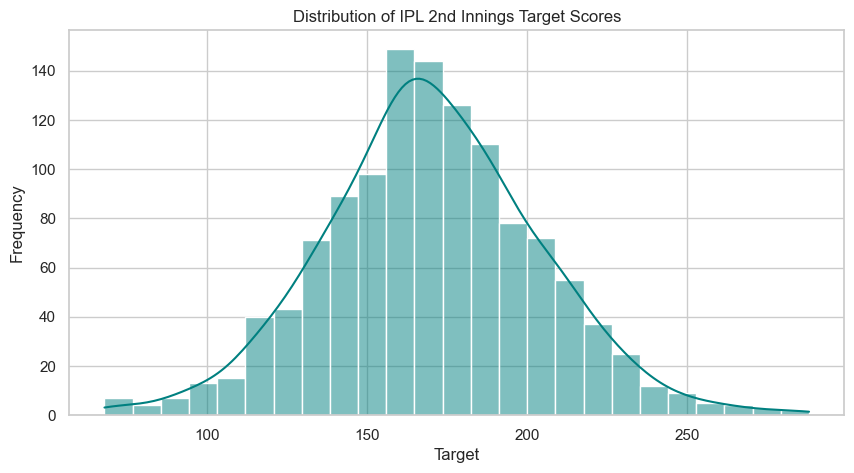

In [3]:
# 1. Target Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df.drop_duplicates('match_id')['target'], bins=25, kde=True, color='teal')
plt.title('Distribution of IPL 2nd Innings Target Scores')
plt.xlabel('Target')
plt.ylabel('Frequency')
os.makedirs('data/plots' if os.path.exists('data') else '../data/plots', exist_ok=True)
plots_dir = 'data/plots' if os.path.exists('data/plots') else '../data/plots'
plt.savefig(os.path.join(plots_dir, 'score_distribution.png'), bbox_inches='tight')
plt.show()

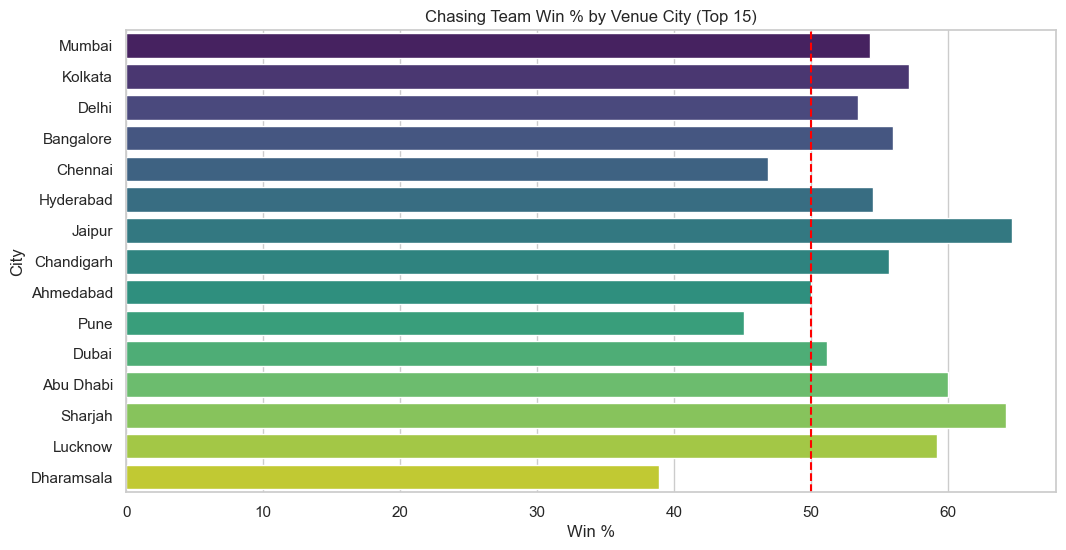

In [4]:
# 2. Chase Win Rate by Venue City (Top 15)
match_cities = df.drop_duplicates('match_id')
city_stats = match_cities.groupby('city').agg(
    total_matches=('result', 'count'),
    chase_wins=('result', 'sum')
).reset_index()
city_stats['chase_win_rate'] = (city_stats['chase_wins'] / city_stats['total_matches']) * 100
top_cities = city_stats.sort_values(by='total_matches', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_cities, x='chase_win_rate', y='city', palette='viridis', hue='city', legend=False)
plt.axvline(50, color='red', linestyle='--')
plt.title('Chasing Team Win % by Venue City (Top 15)')
plt.xlabel('Win %')
plt.ylabel('City')
plt.savefig(os.path.join(plots_dir, 'venue_win_rate.png'), bbox_inches='tight')
plt.show()

## 4. Model Training & Comparison
We split our data temporally (Train: 2008-2022, Test: 2023-2024), handle class imbalance with SMOTE, and compare Logistic Regression and XGBoost.

In [5]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE

cat_cols = ['batting_team', 'bowling_team', 'city']
num_cols = ['balls_left', 'runs_left', 'wickets_in_hand', 'current_run_rate', 'required_run_rate', 'crr_vs_rrr']

# One-hot encode
df_features = df[cat_cols + num_cols]
df_encoded = pd.get_dummies(df_features, columns=cat_cols, dtype=int)

# Temporal split
train_mask = df['year'] <= 2022
test_mask = df['year'] >= 2023

X_train = df_encoded[train_mask]
y_train = df.loc[train_mask, 'result']
X_test = df_encoded[test_mask]
y_test = df.loc[test_mask, 'result']

# Address class imbalance in train
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Baseline Logistic Regression
lr = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)
lr.fit(X_train_res, y_train_res)

# XGBoost Classifier
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42)
xgb.fit(X_train_res, y_train_res)

# Evaluation
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]
print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}\n")

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
print("XGBoost Classifier Report:")
print(classification_report(y_test, y_pred_xgb))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

C:\Users\hp\IPL Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.68      0.89      0.77     16360
           1       0.85      0.59      0.69     16777

    accuracy                           0.74     33137
   macro avg       0.76      0.74      0.73     33137
weighted avg       0.76      0.74      0.73     33137

AUC-ROC: 0.8416

XGBoost Classifier Report:
              precision    recall  f1-score   support

           0       0.69      0.87      0.77     16360
           1       0.83      0.61      0.70     16777

    accuracy                           0.74     33137
   macro avg       0.76      0.74      0.74     33137
weighted avg       0.76      0.74      0.74     33137

AUC-ROC: 0.8368


## 5. Explainability with SHAP
We use SHAP values on a sample of test data to identify global feature importances.

C:\Users\hp\IPL Predictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


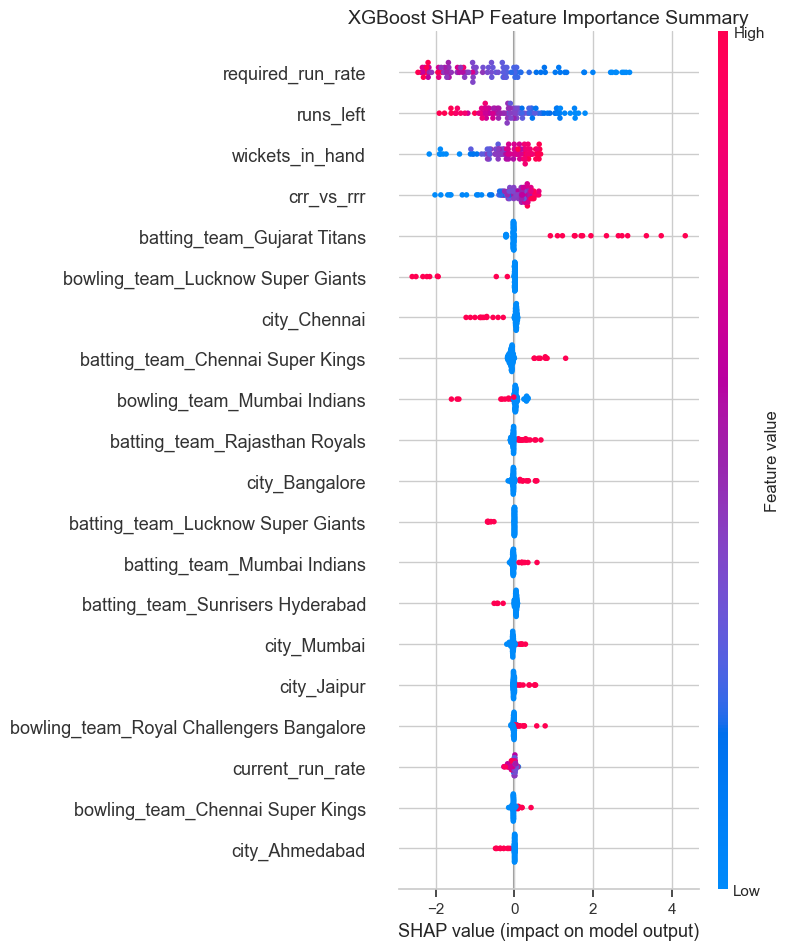

In [6]:
import shap

explainer = shap.TreeExplainer(xgb)
X_sample = X_test.sample(100, random_state=42)
shap_values = explainer(X_sample)

# Plot Summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("XGBoost SHAP Feature Importance Summary", fontsize=14)
plt.savefig(os.path.join(plots_dir, 'shap_summary.png'), bbox_inches='tight')
plt.show()